In [2]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use; papermill / extract_notebook_figures.py
# override these via a cell injected right below this one.

# ── Experiment toggles ──────────────────────────────────────────
BASE_DICTIONARY_1D                  = "Haar"
LEARN_SYNTHESIS_1D                  = False
TIME_EVOLVING_FIELD_ARCHITECTURE_1D = "nerf"
BASE_ACCELERATION_1D                = 10.0

BASE_DICTIONARY_2D                  = "Voronoi"
LEARN_SYNTHESIS_2D                  = True
TIME_EVOLVING_FIELD_ARCHITECTURE_2D = "nerf"
BASE_ACCELERATION_2D                = 10.0

BASE_DICTIONARY_3CH                 = "Haar"
LEARN_SYNTHESIS_3CH                 = True
TIME_EVOLVING_FIELD_ARCHITECTURE_3CH = "nerf"

# Set any BASE_DICTIONARY_* to "Voronoi" for PWC blocks or "Haar" for wavelets.
VORONOI_RESOLUTION = 3   # PWC cells per axis (3 → 3 cells in 1-D, a 3×3 grid in 2-D)

# Changing Bases Using Eulerian Transforms

This section demonstrates the Eulerian change-of-basis formulation. The core idea is that we define a continuous real orthogonal transformation $Q(t)$ on $L^2(\Omega, \mathbb{R}^C)$ governed by

$$\dot{Q}(t) = \mathcal{K}(t) Q(t), \qquad Q(0) = I.$$

Here, $\mathcal{K}(t)$ is a skew-symmetric operator parameterized by two learnable components:

- $U(t, \cdot) \in \mathbb{R}^{N \times R \times C}$: a real spatiotemporal neural field producing $R$ functions spanning an $R$-dimensional subspace.
- $K_R(t) \in \mathbb{R}^{R \times R}$: a time-dependent real matrix produced by a small MLP, converted to $A(t) = K_R(t) - K_R(t)^T$.

The finite-rank generator is

$$\mathcal{K}(t) = U(t)\, A(t)\, U(t)^T,$$

which is skew-symmetric by construction, so each Cayley step $(I - \mathcal{K}/2)^{-1}(I + \mathcal{K}/2)$ is an exact orthogonal map. The preserved inner product is the weighted real product

$$\langle f, g\rangle = \frac{1}{N}\sum_n e^{\ell_n}\, f(x_n)\cdot g(x_n).$$


In [3]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import functools
sys.path.append('..')  # for notebook_helpers in notebooks/

from notebook_helpers import (
    visualize_generator_U,
    plot_signal_1d,
    show_scalar_2d,
)
from infidictionary.neural_isometries import (
    EulerianIsometry, ChannelOrthogonalIsometry, ChainedIsometry,
)
from infidictionary.networks import NerfConditionalField
from infidictionary.dictionaries import FourierDictionary, HaarWaveletDictionary, VoronoiPWC
from infidictionary.domain_samplers import SquareSampler
from infidictionary.utils import pairwise_inner_product, norm2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)


In [4]:
def make_dictionary(
    kind: str, domain_dim: int, num_channels: int = 1, learn_synthesis: bool = True,
):
    """Construct a real Fourier, Haar, or tessellated Voronoi starting dictionary."""
    if kind == "Fourier":
        return FourierDictionary(
            domain_dim=domain_dim, num_channels=num_channels, steepness=2.0,
            learn_synthesis=learn_synthesis,
        )
    if kind == "Haar":
        return HaarWaveletDictionary(
            domain_dim=domain_dim, num_channels=num_channels,
            learn_synthesis=learn_synthesis,
            synthesis_tail_probability=0.01,
        )
    if kind == "Voronoi":
        return VoronoiPWC(
            resolution=VORONOI_RESOLUTION,
            dimension=domain_dim,
            num_channels=num_channels,
            learn_synthesis=learn_synthesis,
        )
    raise ValueError(f"unknown dictionary kind: {kind}; use Fourier, Haar, or Voronoi")


def make_field_partial(architecture: str):
    if architecture == "nerf":
        return functools.partial(
            NerfConditionalField,
            hidden_dims=[256, 256, 256],
            activation=torch.nn.SiLU,
            nerf_n_levels=8,
            nerf_n_base=64,
            nerf_freq_min=1.0,
            nerf_freq_max=24.0,
        )
    raise ValueError(f"unknown field architecture: {architecture}")


def make_isometry(
    coords_dim: int,
    architecture: str,
    base_acceleration: float,
    rank: int,
    n_time_freqs: int,
    channels_dim: int = 1,
    gradient_checkpointing: bool = False,
):
    eulerian_partial = functools.partial(
        EulerianIsometry,
        base_acceleration=base_acceleration,
        rank=rank,
        n_time_freqs=n_time_freqs,
        kr_hidden_dims=(64, 64),
        gradient_checkpointing=gradient_checkpointing,
        max_gen_norm=1.0,
        scalar_field_partial=make_field_partial(architecture),
    )
    eulerian = eulerian_partial(coords_dim=coords_dim, channels_dim=channels_dim).to(device)
    # A scalar field has no channels to mix. Multi-channel examples always
    # begin with a Haar-random channel rotation before Eulerian transport.
    if channels_dim == 1:
        return eulerian, eulerian

    chain = ChainedIsometry(
        coords_dim=coords_dim,
        channels_dim=channels_dim,
        isometries_partial=[
            functools.partial(ChannelOrthogonalIsometry, hidden_dims=(64, 64)),
            eulerian_partial,
        ],
    ).to(device)
    return chain, chain.isometries[1]


def select_indices(kind: str, basis, domain_dim: int):
    """Small atom set for plotting plus a probability-based set for Gram checks."""
    if kind == "Voronoi":
        all_indices = basis.get_high_probability_indices(0.0)
        return all_indices[:5].to(device), all_indices.to(device)
    if kind == "Haar":
        if domain_dim == 1:
            demo = torch.tensor([[-1, 0, 0, 0], [0, 0, 1, 0], [1, 0, 1, 0], [1, 1, 1, 0], [2, 0, 1, 0]])
        elif domain_dim == 2:
            demo = torch.tensor([[-1, 0, 0, 0, 0], [0, 0, 0, 1, 0], [0, 0, 0, 2, 0], [0, 0, 0, 3, 0], [1, 1, 0, 1, 0]])
        else:
            raise ValueError("this notebook only visualizes 1D and 2D dictionaries")
        return demo.to(device), basis.get_high_probability_indices(1e-3).to(device)
    if kind != "Fourier":
        raise ValueError(f"unknown dictionary kind: {kind}")
    if domain_dim == 1:
        demo = torch.tensor([[0, 0], [1, 0], [-1, 0], [2, 0], [-2, 0]], dtype=torch.long)
    elif domain_dim == 2:
        demo = torch.tensor([[0, 0, 0], [1, 0, 0], [-1, 0, 0], [0, 1, 0], [1, 1, 0]], dtype=torch.long)
    else:
        raise ValueError("this notebook only visualizes 1D and 2D dictionaries")
    gram = basis.get_high_probability_indices(1e-3)
    return demo.to(device), gram.to(device)


## A Simple 1-D Experiment

The smallest end-to-end example on $[0,1]$. The initial basis (`BASE_DICTIONARY_1D`) and the Eulerian isometry come from the parameters cell. For multi-channel examples, the notebook automatically prepends a `ChannelOrthogonalIsometry`; a one-channel field has nothing to mix. We push a few atoms through and check that the real inner products are preserved.

The initial dictionary is the real Fourier basis with probability-based finite atom subsets.

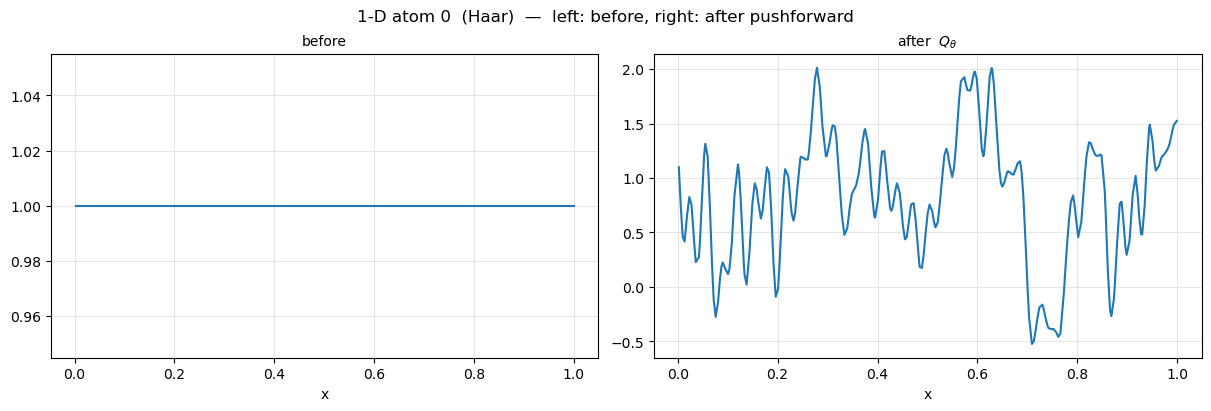

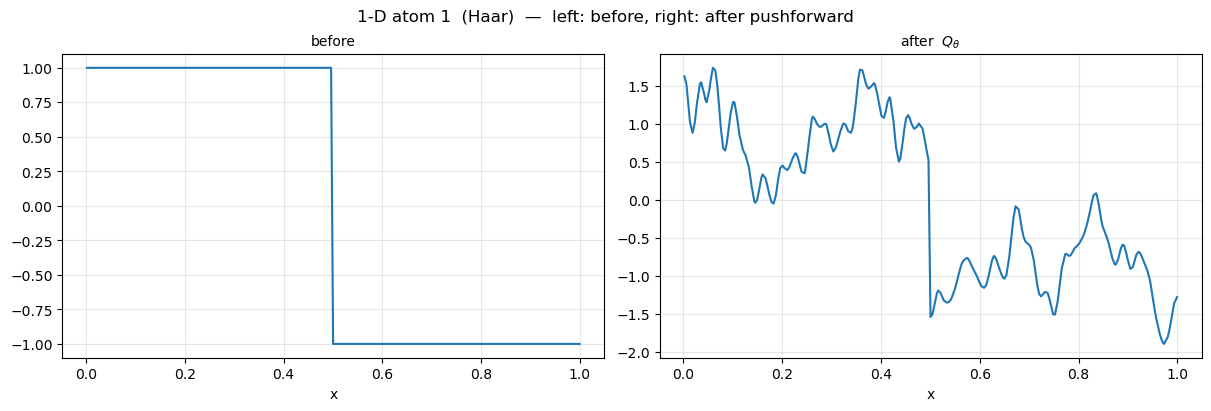

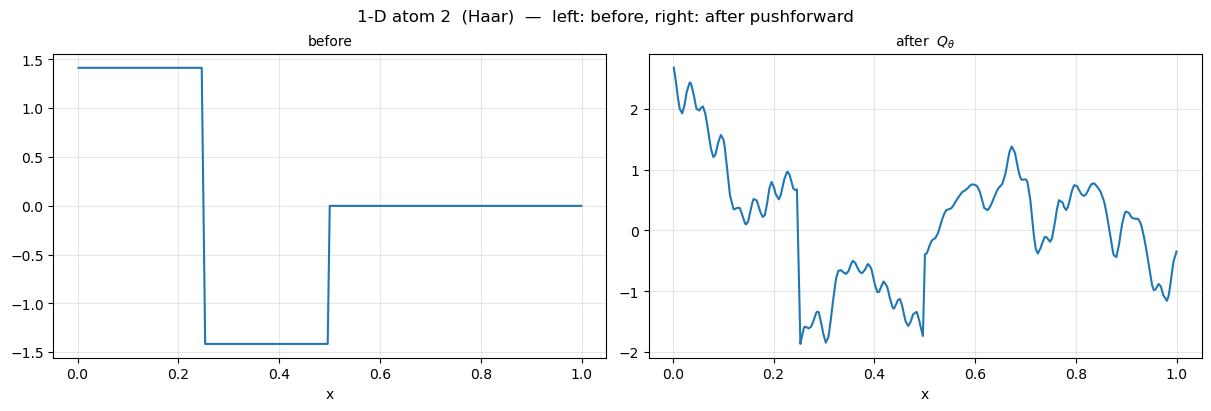

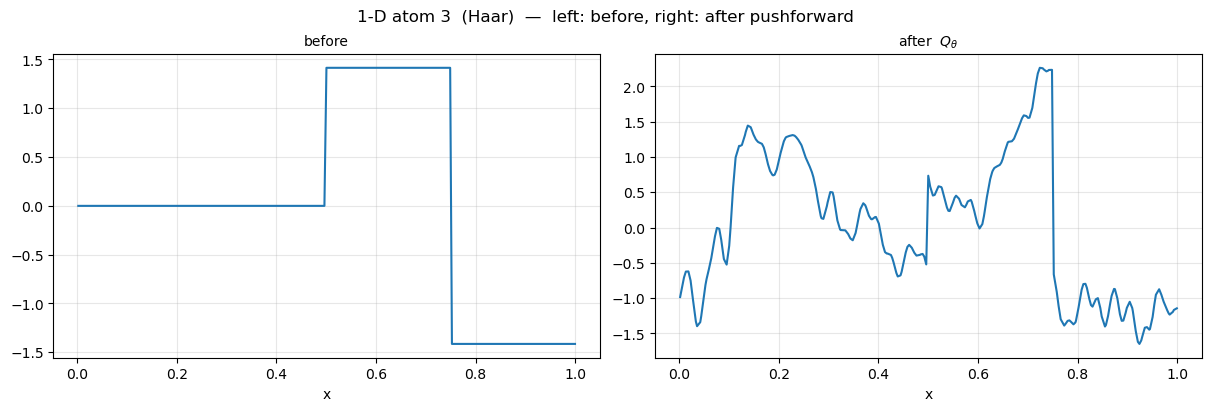

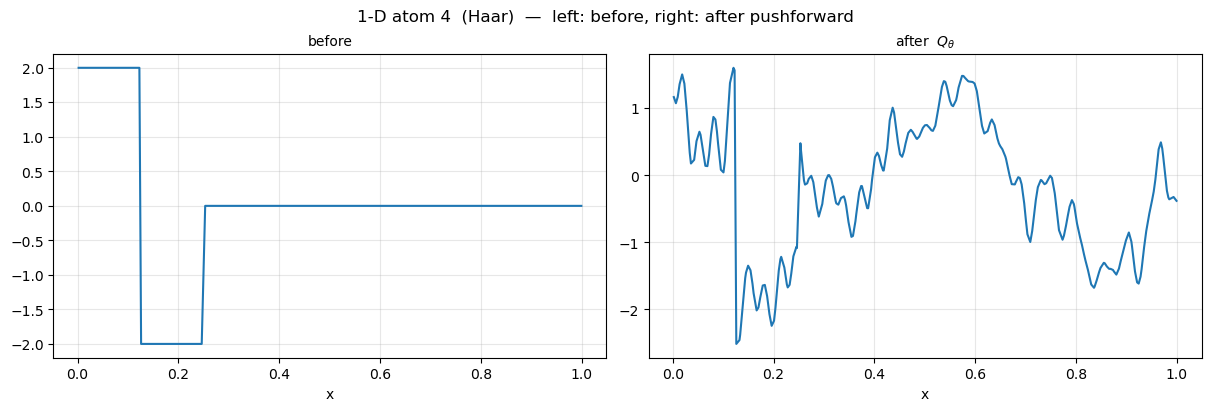

In [5]:
%autoreload 2
torch.manual_seed(0)

isometry_1d, eulerian_1d = make_isometry(
    coords_dim=1, architecture=TIME_EVOLVING_FIELD_ARCHITECTURE_1D,
    base_acceleration=BASE_ACCELERATION_1D,
    rank=8, n_time_freqs=12,
)
basis_1d = make_dictionary(BASE_DICTIONARY_1D, domain_dim=1, learn_synthesis=LEARN_SYNTHESIS_1D)
idx_1d, gram_idx_1d = select_indices(BASE_DICTIONARY_1D, basis_1d, domain_dim=1)

N_1d = 256
x_1d = SquareSampler(domain_dim=1, stratified=True, add_noise=True).sample(N_1d).to(device)   # (N, 1) on [0,1]
src_1d = basis_1d.get_atoms(x_1d, idx_1d)                                            # (A, N, 1) real

isometry_1d.shuffle_model_state(num_steps=20)
isometry_1d.eval()
_, _, tgt_1d = isometry_1d.pushforward(
    x_1d, torch.zeros(N_1d, device=device), src_1d, rot_start_time=0.0, rot_end_time=1.0,
)

# Left = before, right = after the chained pushforward.
for a in range(idx_1d.shape[0]):
    fig, (axb, axa) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    plot_signal_1d(x_1d[:, 0], src_1d[a], title='before', ax=axb)
    plot_signal_1d(x_1d[:, 0], tgt_1d[a], title=r'after  $Q_\theta$', ax=axa)
    fig.suptitle(fr'1-D atom {a}  ({BASE_DICTIONARY_1D})  —  left: before, right: after pushforward')
    plt.show()

### 1-D Gram check

The pushforward is orthogonal, so $G_{ab} = \langle Q\phi_a, Q\phi_b\rangle$ must equal the initial $\langle \phi_a, \phi_b\rangle$. Both bases are orthonormal, so the initial Gram is the identity $\delta_{ab}$. We sample the quadrature points **independently** for the two Grams — matching heatmaps reflect the $L^2$ isometry, not a shared point set.

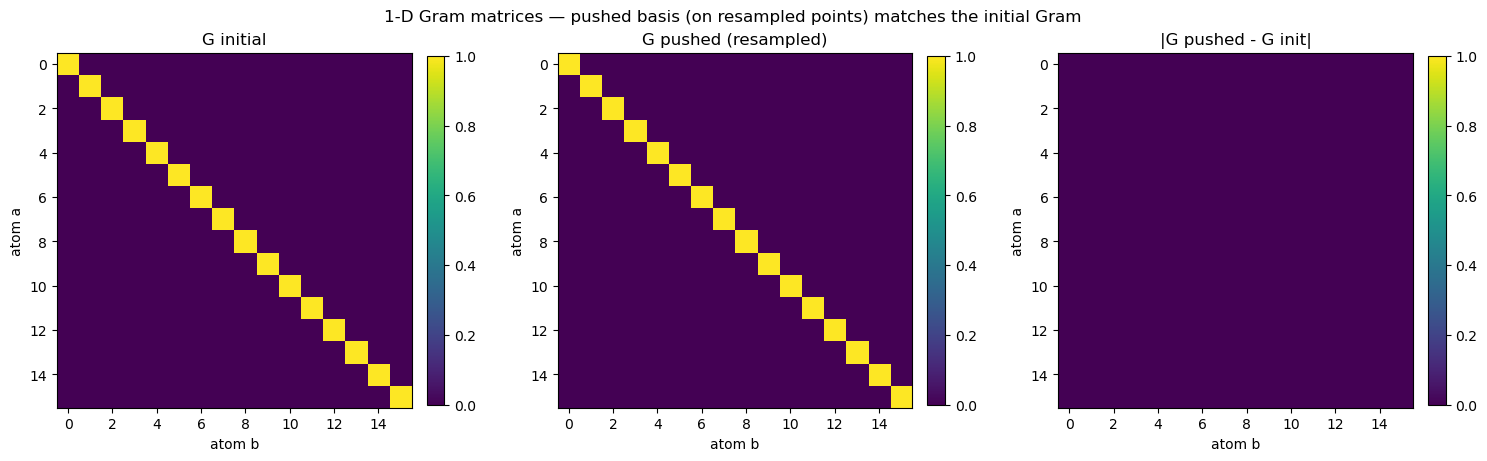

max |G_pushed - G_init| = 8.881784197001252e-16


In [6]:
%autoreload 2
# Independent quadrature points for the initial vs the pushed Gram.
lad_1d = torch.zeros(N_1d, device=device)
x_init = SquareSampler(domain_dim=1, stratified=True, add_noise=True).sample(N_1d).to(device)
x_push = SquareSampler(domain_dim=1, stratified=True, add_noise=True).sample(N_1d).to(device)

atoms_init_1d = basis_1d.get_atoms(x_init, gram_idx_1d)
atoms_push_1d = basis_1d.get_atoms(x_push, gram_idx_1d)
with torch.no_grad():
    _, _, atoms_push_1d = isometry_1d.pushforward(
        x_push, lad_1d, atoms_push_1d, rot_start_time=0.0, rot_end_time=1.0,
    )
    G_init_1d   = pairwise_inner_product(atoms_init_1d, atoms_init_1d, lad_1d)
    G_pushed_1d = pairwise_inner_product(atoms_push_1d, atoms_push_1d, lad_1d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
vmin = min(G_init_1d.min().item(), G_pushed_1d.min().item())
vmax = max(G_init_1d.max().item(), G_pushed_1d.max().item())
for ax, G, title in zip(axes, [G_init_1d, G_pushed_1d, G_pushed_1d - G_init_1d],
                        ['G initial', 'G pushed (resampled)', '|G pushed - G init|']):
    im = ax.imshow(G.detach().cpu(), cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.set_xlabel('atom b'); ax.set_ylabel('atom a')
fig.suptitle('1-D Gram matrices — pushed basis (on resampled points) matches the initial Gram')
plt.show()
print('max |G_pushed - G_init| =', (G_pushed_1d - G_init_1d).abs().max().item())

### 1-D generator field $U$

The generator $\mathcal{K}_\theta(t) = U_\theta(t)\,A_\theta(t)\,U_\theta(t)^\ast$ lives on the **Eulerian link** (`eulerian_1d`); the channel-orthogonal link has no such field. Each column $u_r(t,\cdot)$ is a real 1-D signal (amplitude/phase); the bottom row is $|\exp(K_R - K_R^T)|$.

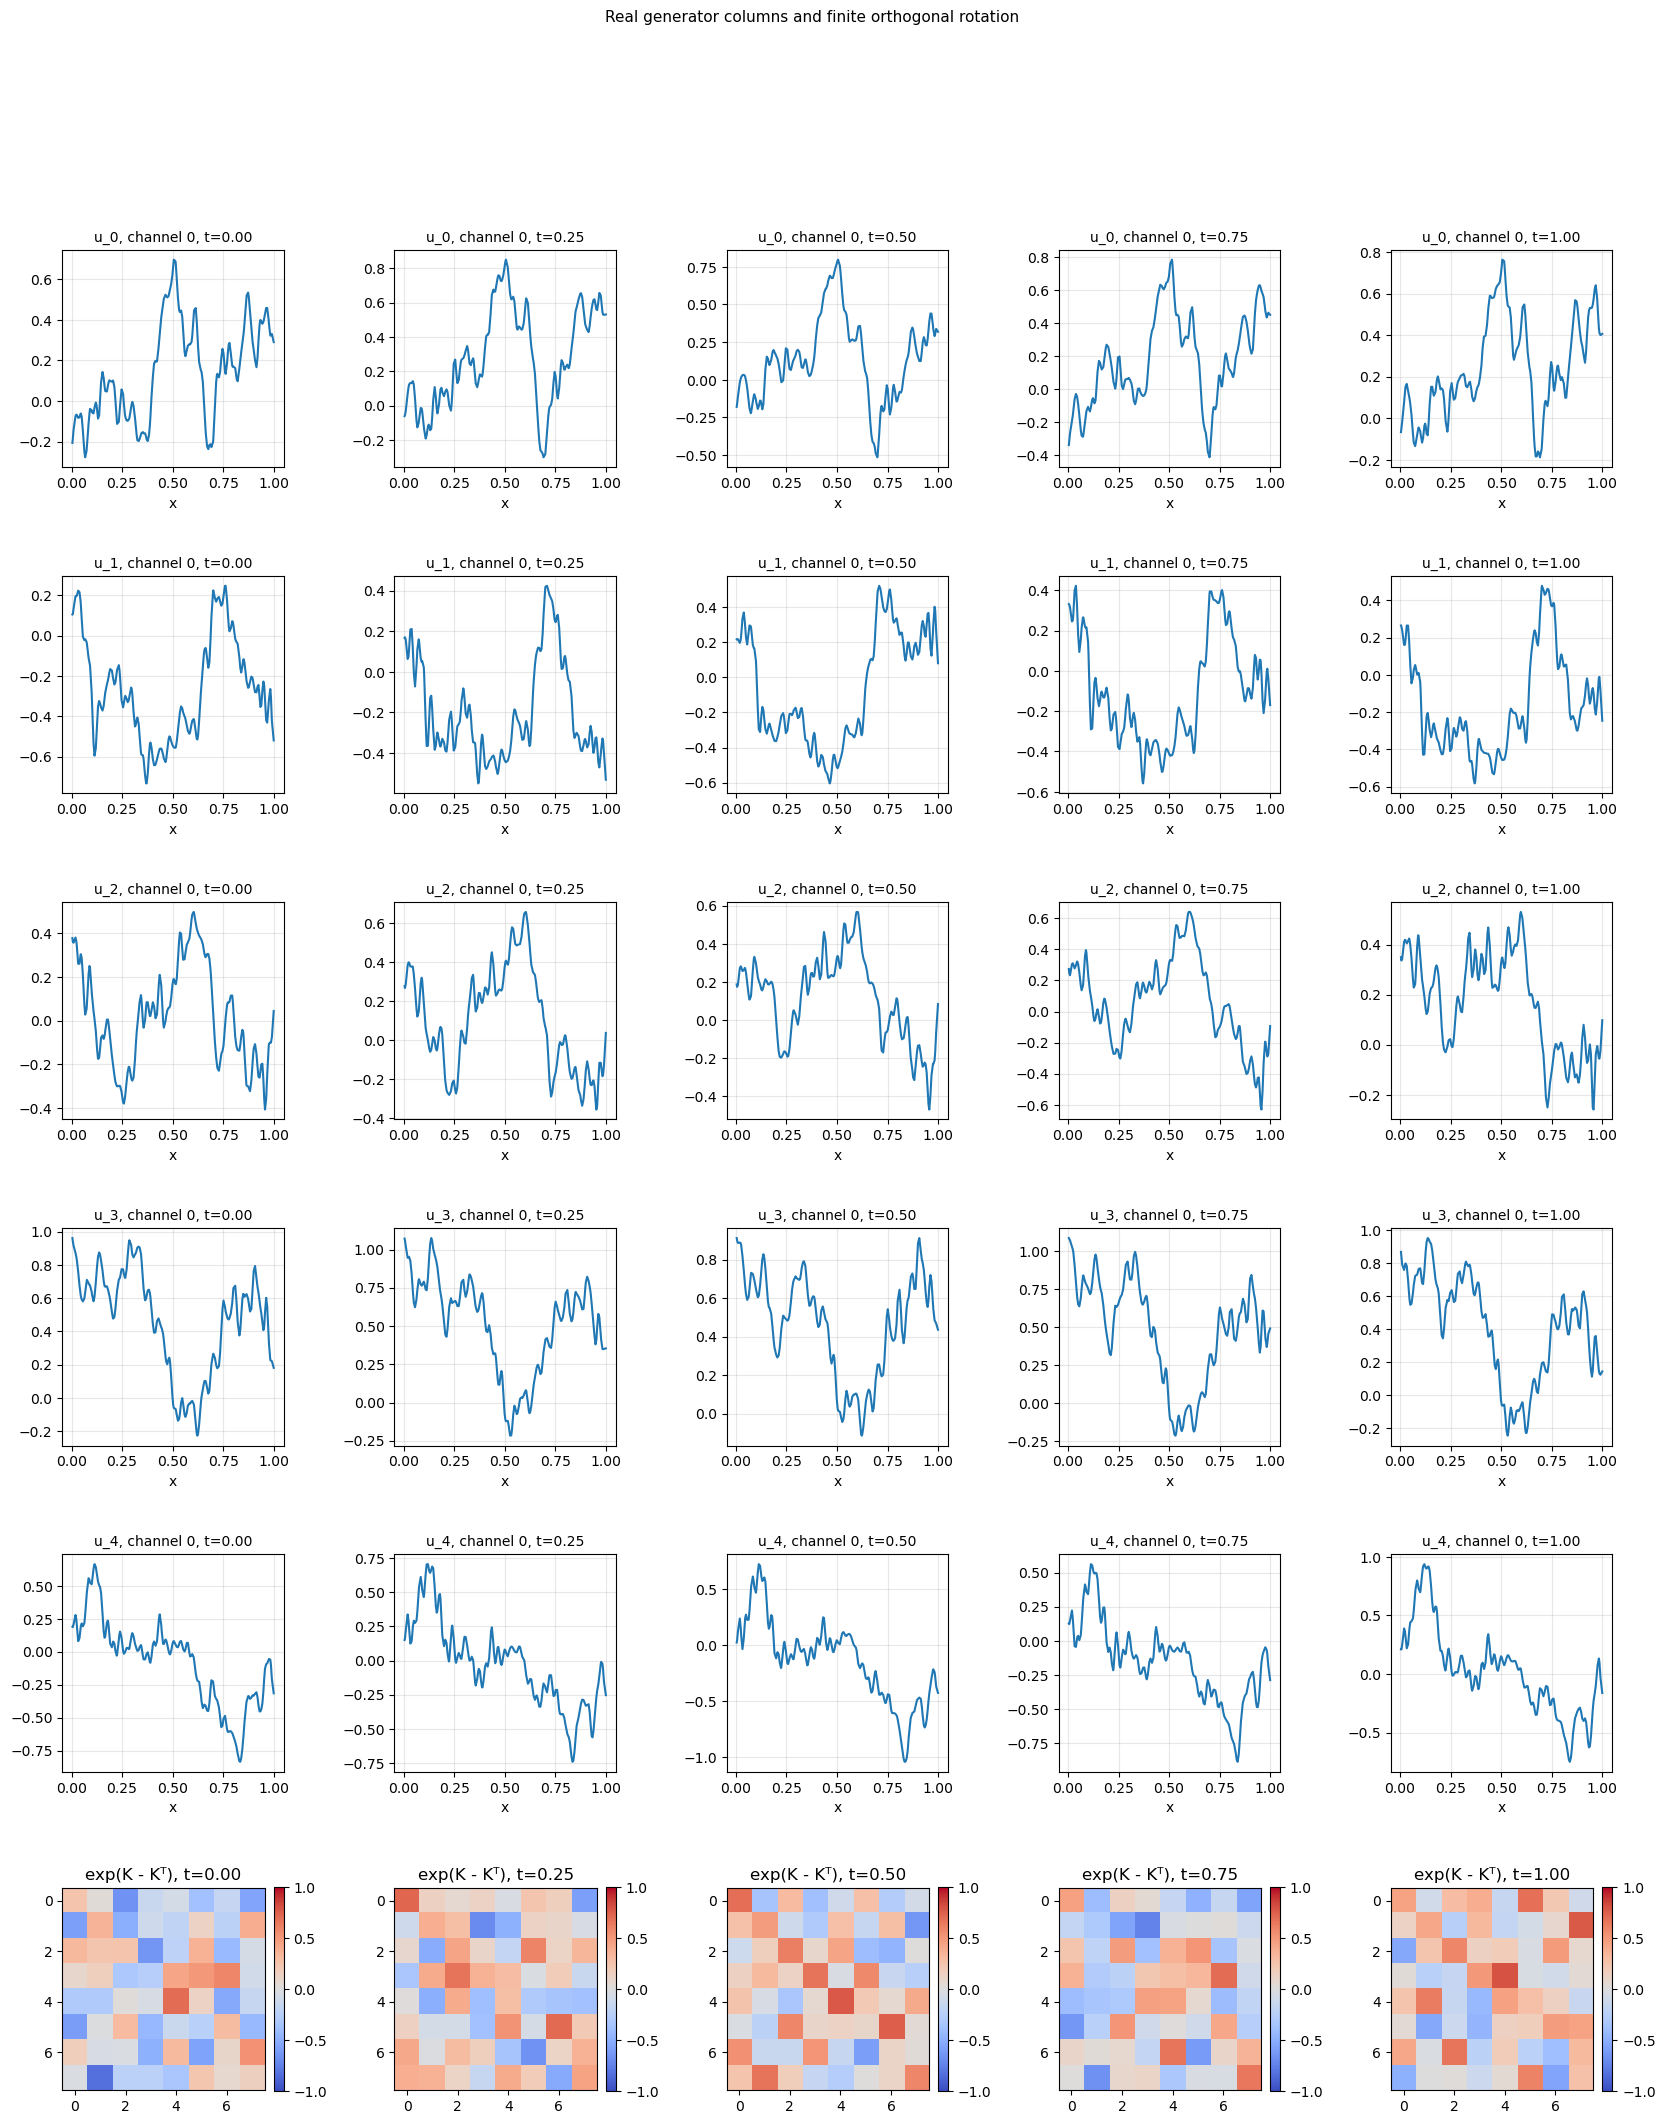

In [7]:
%autoreload 2
# Generator field U(t, .) for the Eulerian link of the chain. In 1-D each column
# u_r(t, .) is a real signal, so visualize_generator_U draws it as scalar curves
# and the bottom row shows exp(K_R - K_R^T). The chain itself is not an
# EulerianIsometry, so we pass its Eulerian link (eulerian_1d) directly.
coords_vis_1d = SquareSampler(domain_dim=1, stratified=True, add_noise=True).sample(200).to(device)
timesteps_1d = torch.linspace(0.0, 1.0, 5)

visualize_generator_U(eulerian_1d, coords_vis_1d, timesteps_1d, device)

## 2-D Experiment

The same pipeline on $[0,1]^2$, single channel. The basis, synthesis choice, generator architecture, and base acceleration are all set by the `*_2D` parameters cell.

Build the isometry from the toggles:

In [8]:
%autoreload 2
torch.manual_seed(0)
isometry, eulerian_2d = make_isometry(
    coords_dim=2, architecture=TIME_EVOLVING_FIELD_ARCHITECTURE_2D,
    base_acceleration=BASE_ACCELERATION_2D,
    rank=10, n_time_freqs=16, gradient_checkpointing=True,
)

Push the chosen atoms through the isometry (solving the ODE) and domain-color them before/after:

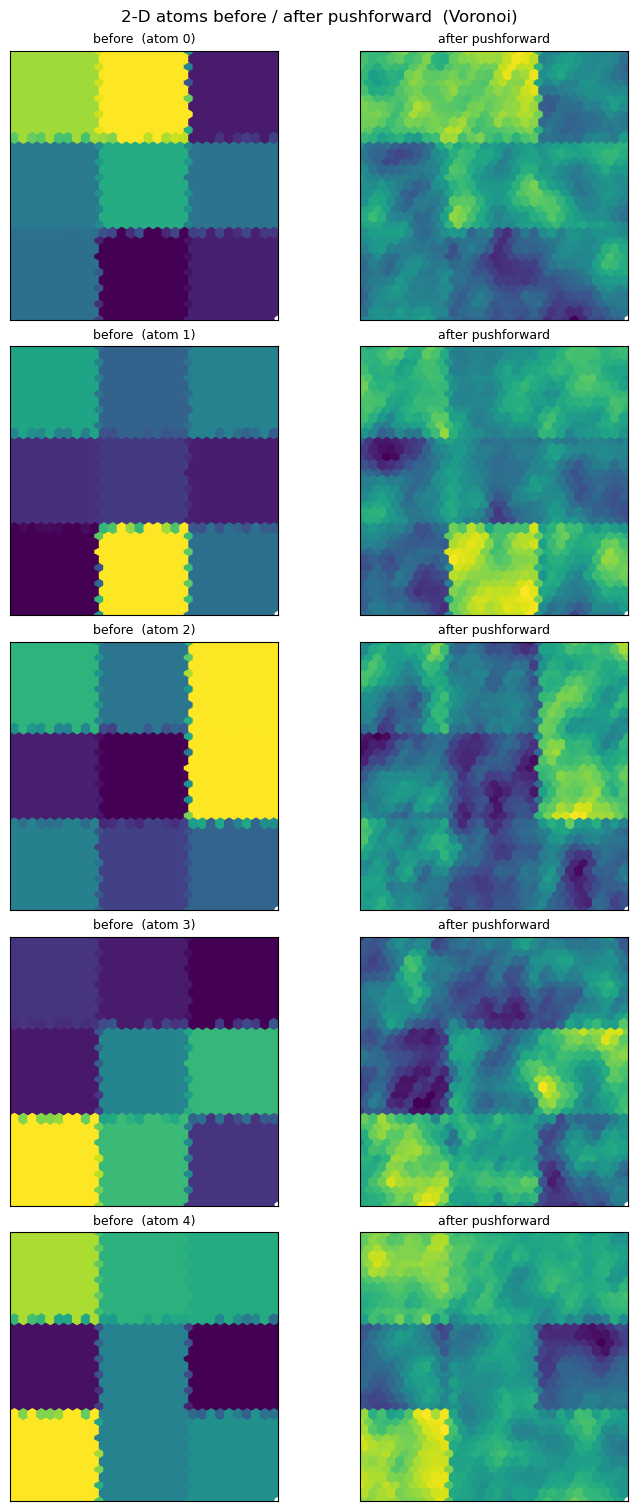

In [9]:
%autoreload 2
torch.manual_seed(0)
basis_2d = make_dictionary(BASE_DICTIONARY_2D, domain_dim=2, learn_synthesis=LEARN_SYNTHESIS_2D)
demo_idx_2d, gram_idx_2d = select_indices(BASE_DICTIONARY_2D, basis_2d, domain_dim=2)

N_per_dim = 64
rot_end_time = 1.0
xy = SquareSampler(stratified=True, add_noise=True).sample(N_per_dim).to(device)
src_field = basis_2d.get_atoms(xy, demo_idx_2d)

isometry.shuffle_model_state(num_steps=20)
isometry.eval()
_, _, tgt_field = isometry.pushforward(
    xy, torch.zeros(xy.shape[0], device=device), src_field, rot_start_time=0.0, rot_end_time=rot_end_time,
)

# Single-channel fields are shown as scalar heatmaps.
n_show = demo_idx_2d.shape[0]
fig, axes = plt.subplots(n_show, 2, figsize=(7, 3.0 * n_show), constrained_layout=True)
for i in range(n_show):
    show_scalar_2d(axes[i, 0], xy, src_field[i], title=f'before  (atom {i})')
    show_scalar_2d(axes[i, 1], xy, tgt_field[i], title='after pushforward')
fig.suptitle(f'2-D atoms before / after pushforward  ({BASE_DICTIONARY_2D})')
plt.show()

Inner-product (Gram) check, with quadrature points sampled **independently** for the original and pushed bases — the heatmaps should still match (the transform is an isometry), up to Monte-Carlo error between the two point clouds:

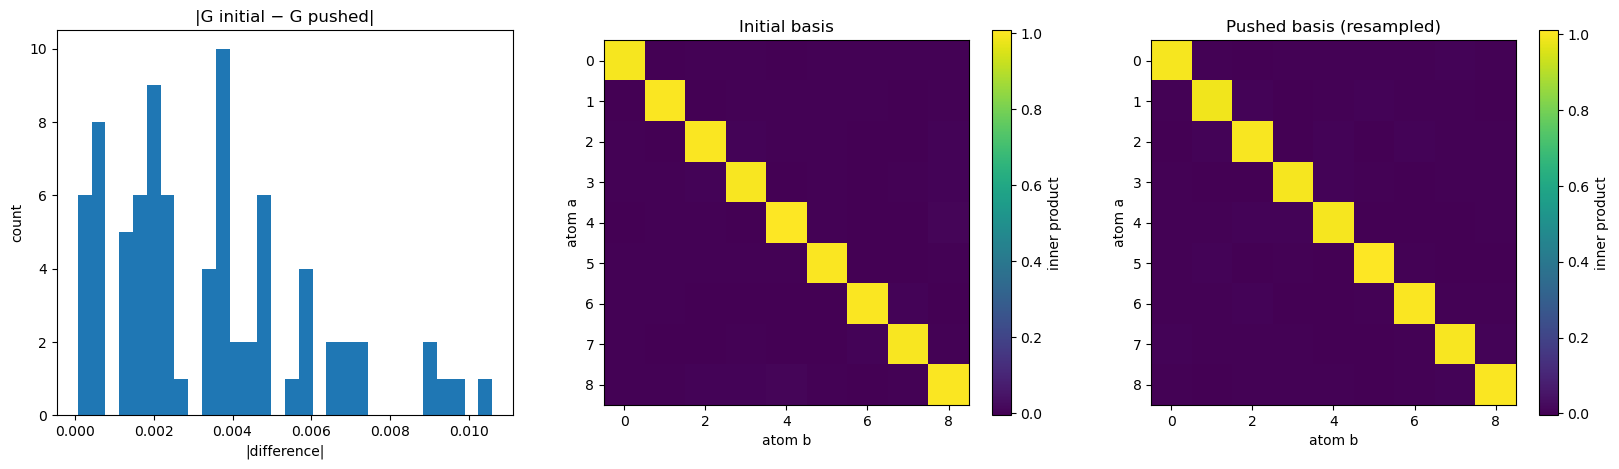

max |G_pushed - G_init| = 0.010583294837827384


In [10]:
%autoreload 2
# Independent quadrature points for the original vs the pushed basis.
coords_init = SquareSampler(stratified=True, add_noise=True).sample(N_per_dim).to(device)
coords_push = SquareSampler(stratified=True, add_noise=True).sample(N_per_dim).to(device)
atoms_init = basis_2d.get_atoms(coords_init, gram_idx_2d)
atoms_push = basis_2d.get_atoms(coords_push, gram_idx_2d)
_, _, atoms_push = isometry.pushforward(
    coords_push, torch.zeros(coords_push.shape[0], device=device), atoms_push,
    rot_start_time=0.0, rot_end_time=rot_end_time,
)

# Gram matrices are real; show <.,.>.
G_init = pairwise_inner_product(atoms_init, atoms_init)
G_pushed = pairwise_inner_product(atoms_push, atoms_push)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
m = axes[1].imshow(G_init.detach().cpu(), cmap='viridis'); fig.colorbar(m, ax=axes[1], label='inner product')
axes[1].set_title('Initial basis'); axes[1].set_xlabel('atom b'); axes[1].set_ylabel('atom a')
m = axes[2].imshow(G_pushed.detach().cpu(), cmap='viridis'); fig.colorbar(m, ax=axes[2], label='inner product')
axes[2].set_title('Pushed basis (resampled)'); axes[2].set_xlabel('atom b'); axes[2].set_ylabel('atom a')
axes[0].hist((G_init - G_pushed).abs().flatten().detach().cpu(), bins=30)
axes[0].set_title('|G initial − G pushed|'); axes[0].set_xlabel('|difference|'); axes[0].set_ylabel('count')
plt.show()
print('max |G_pushed - G_init| =', (G_init - G_pushed).abs().max().item())

## Generator field $U$ and rotation $K_R$

On the Eulerian link (`eulerian_2d`), at several timesteps: rows $0..R-1$ are the columns $u_r(t,\cdot)$ of $U$ (hue = phase, brightness = amplitude); row $R$ is $|\exp(K_R - K_R^T)|$, the magnitude of the orthogonal finite rotation.

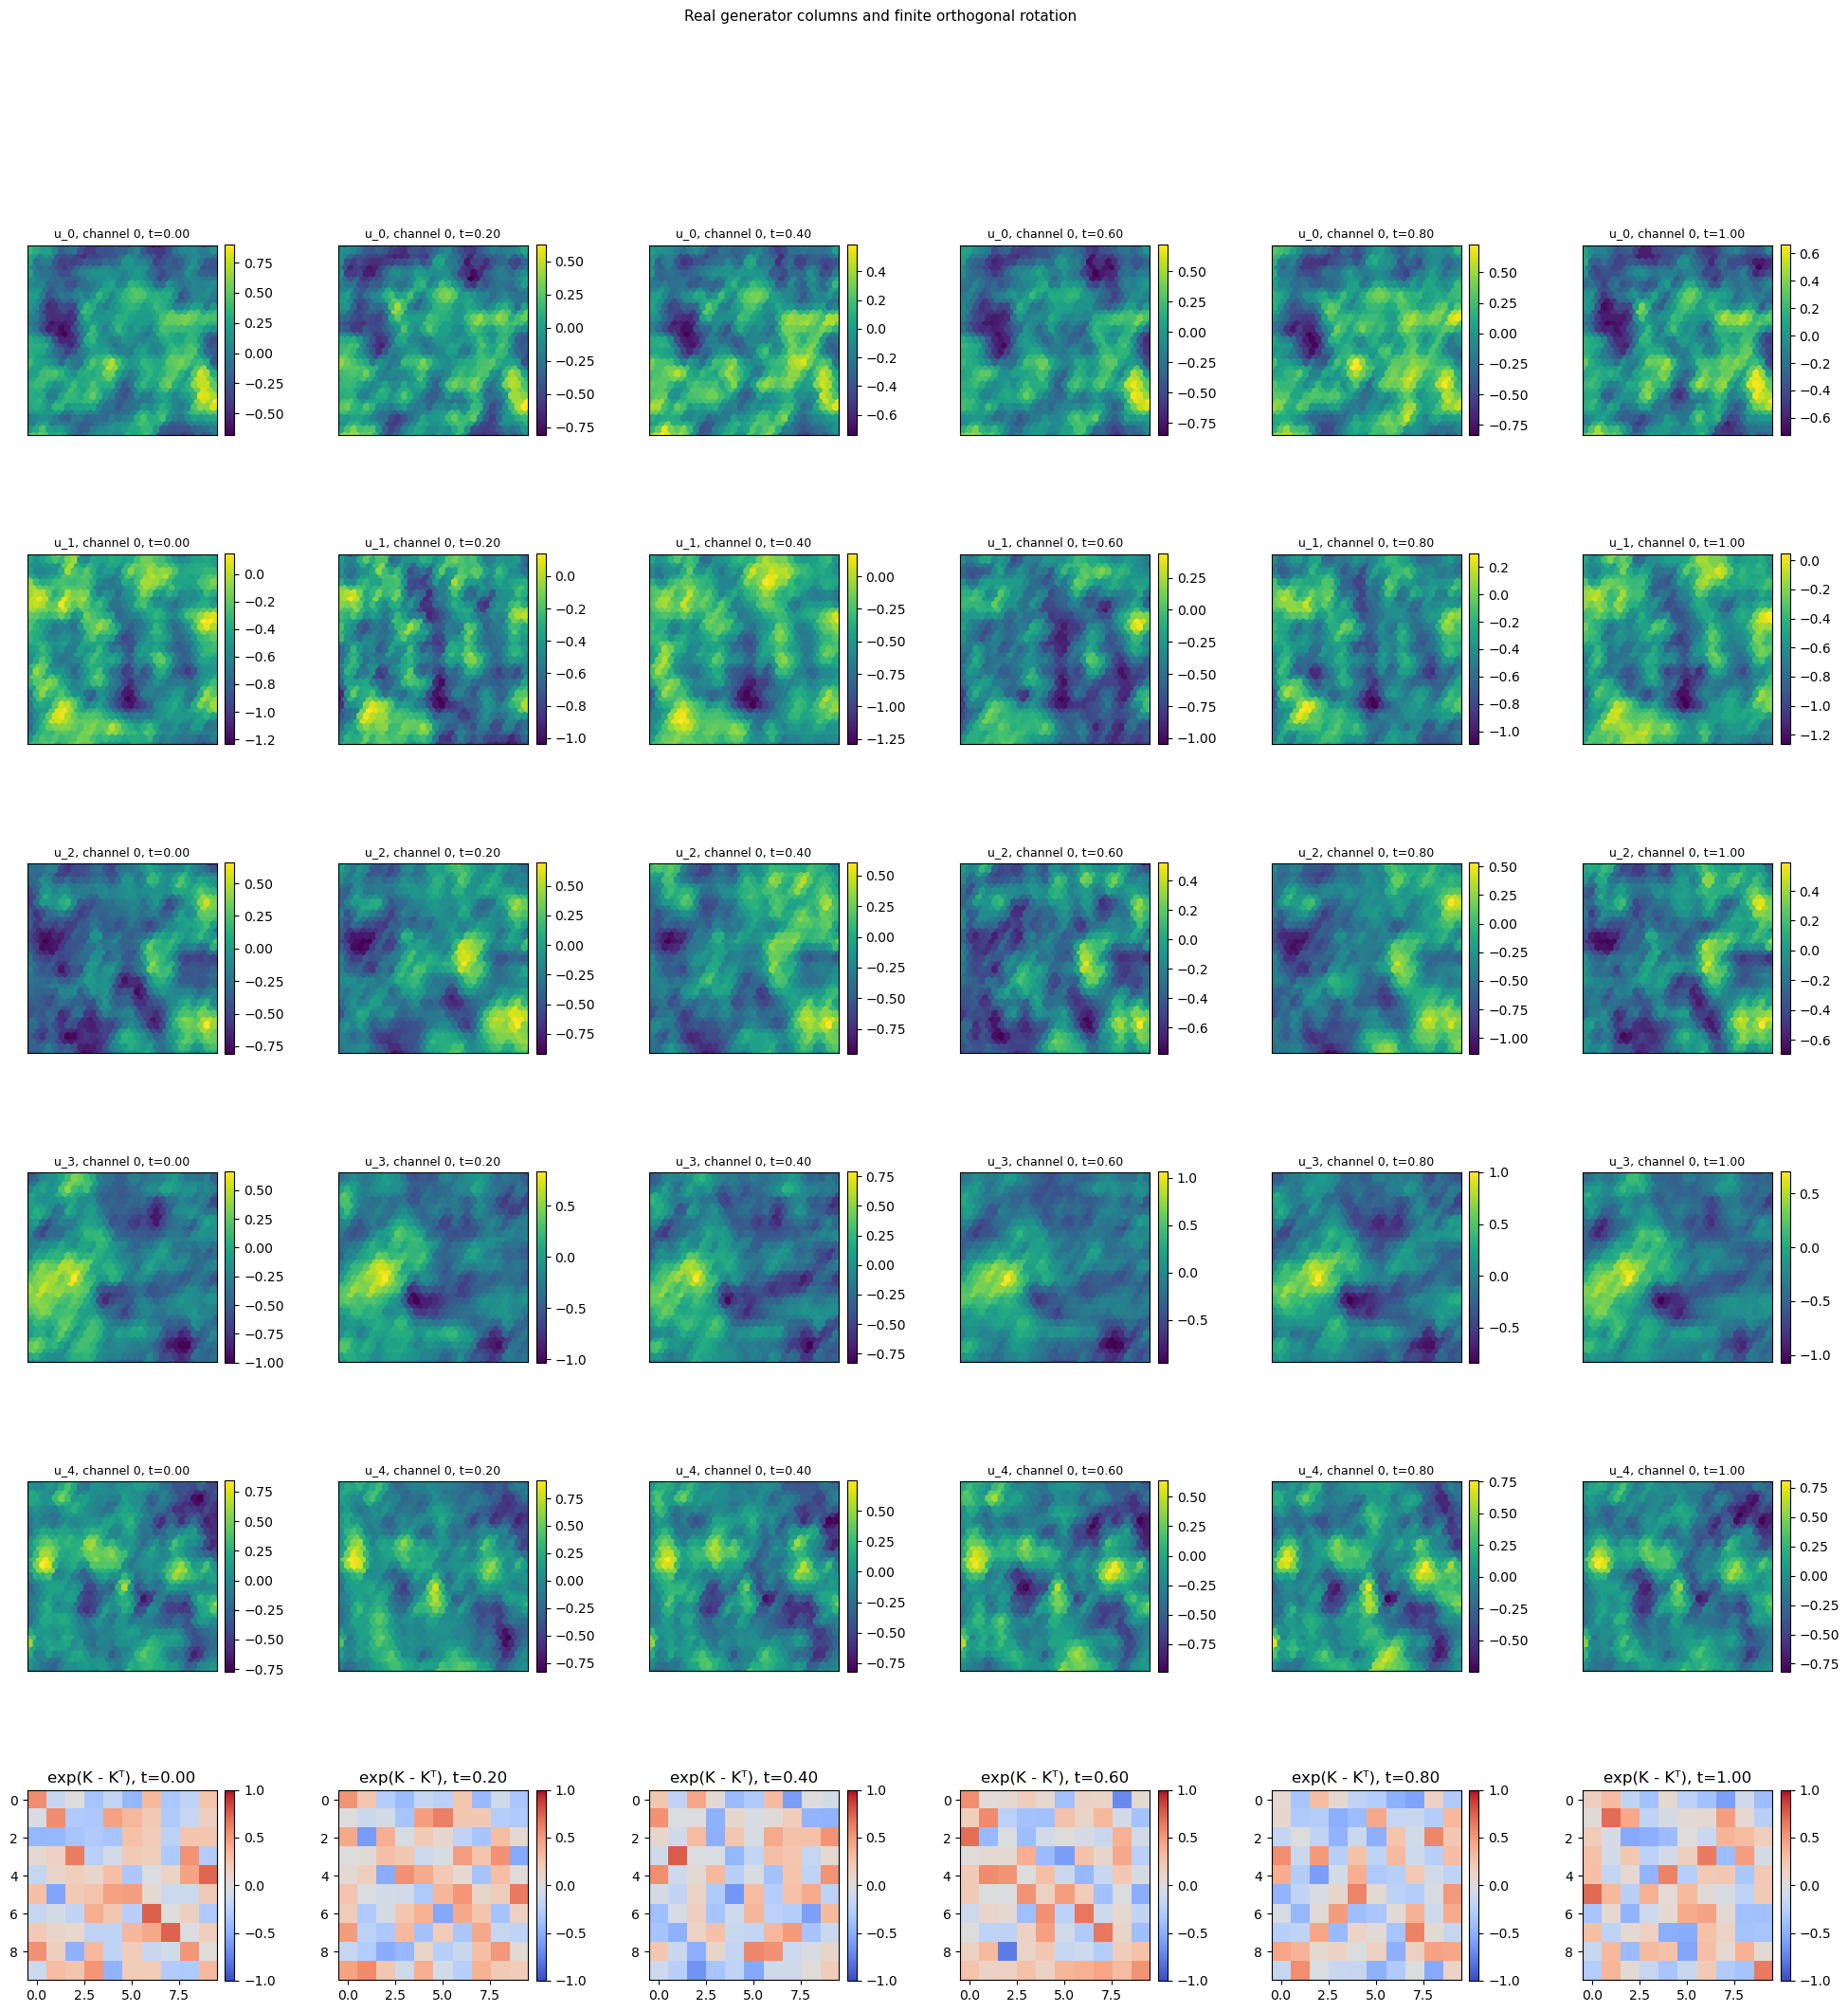

In [11]:
%autoreload 2
# Generator field lives on the Eulerian link; pass eulerian_2d (the chain itself
# is not an EulerianIsometry).
timesteps = torch.linspace(0.0, 1.0, 6)
coords_vis = SquareSampler(stratified=True, add_noise=True).sample(80).to(device)
visualize_generator_U(eulerian_2d, coords_vis, timesteps, device)

Pushforward / pullback consistency: $Q_s^t Q_t^s f = (Q_t^s)^\ast Q_t^s f = f$. We visualize $f$, $Q_t^s f$, and $Q_s^t Q_t^s f$ and report the residual.

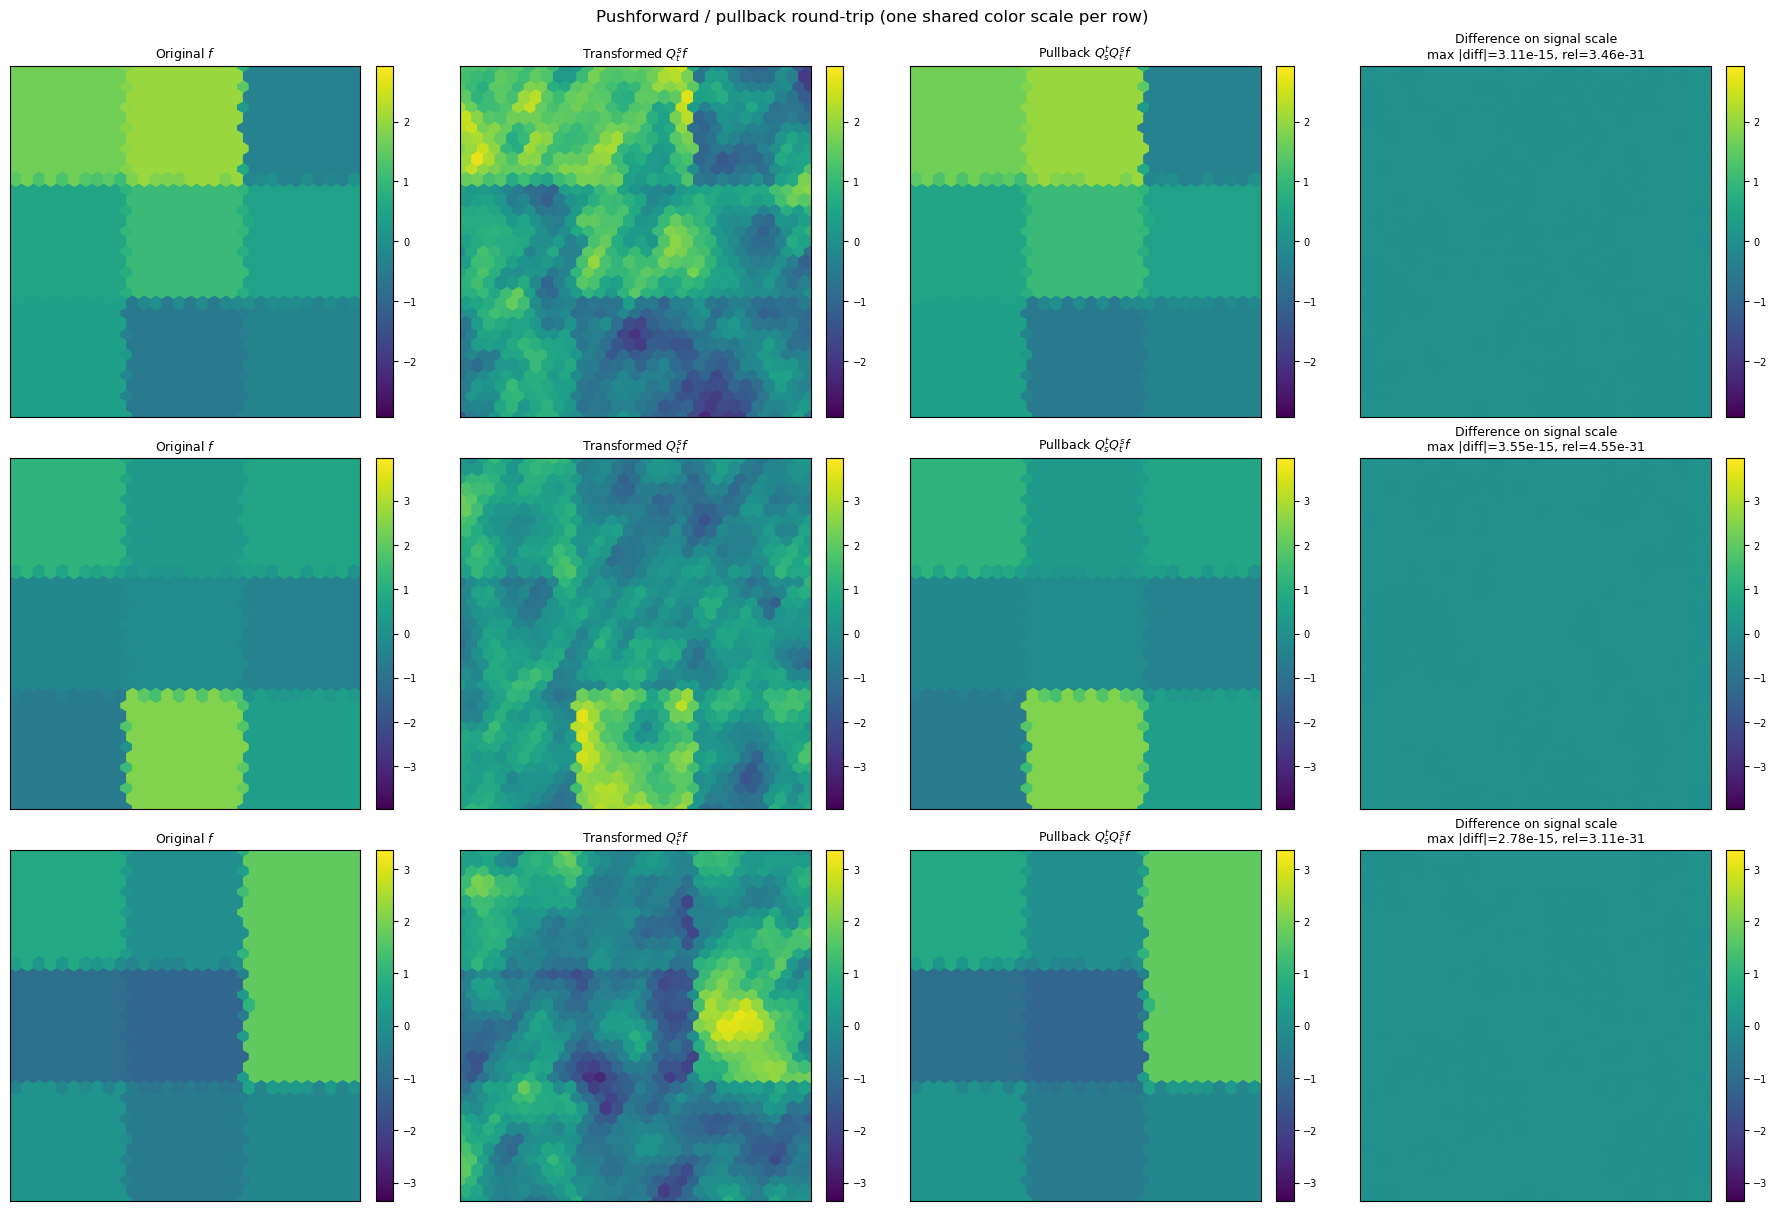

Round-trip relative residual per atom: ['3.46e-31', '4.55e-31', '3.11e-31']
Round-trip max absolute residual per atom: ['3.11e-15', '3.55e-15', '2.78e-15']


In [12]:
%autoreload 2
rot_start_time, rot_end_time_rt, inner_steps = 0.0, 5.0, 50
isometry.shuffle_model_state(num_steps=inner_steps)
isometry.eval()

coords = SquareSampler(stratified=True, add_noise=True).sample(64).to(device)
f = basis_2d.get_atoms(coords, demo_idx_2d[:3])   # 3 atoms

coords, logabsdet, f_t = isometry.pushforward(
    coords, torch.zeros(coords.shape[0], device=device), f,
    rot_start_time=rot_start_time, rot_end_time=rot_end_time_rt,
)
coords, logabsdet, f_tb = isometry.pullback(
    coords, logabsdet, f_t, rot_start_time=rot_start_time, rot_end_time=rot_end_time_rt,
)
diff = f_tb - f

rel = norm2(diff, logabsdet) / norm2(f, logabsdet).clamp(min=1e-12)
max_abs_diff = diff.reshape(diff.shape[0], -1).abs().max(dim=1).values

titles = [
    'Original $f$',
    'Transformed $Q_t^s f$',
    'Pullback $Q_s^t Q_t^s f$',
    'Difference $Q_s^t Q_t^s f - f$',
]
fig, axes = plt.subplots(len(f), 4, figsize=(18, 4 * len(f)), constrained_layout=True)
for i in range(len(f)):
    signal_scale = torch.stack([f[i].abs().max(), f_t[i].abs().max(), f_tb[i].abs().max()]).max().item()
    signal_scale = max(signal_scale, 1e-12)
    row = [f[i], f_t[i], f_tb[i], diff[i]]
    for j, (field, title) in enumerate(zip(row, titles)):
        hb = show_scalar_2d(
            axes[i, j],
            coords,
            field,
            title=title,
            vmin=-signal_scale,
            vmax=signal_scale,
        )
        cbar = fig.colorbar(hb, ax=axes[i, j], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=7)
    axes[i, 3].set_title(
        f'Difference on signal scale\nmax |diff|={max_abs_diff[i].item():.2e}, rel={rel[i].item():.2e}',
        fontsize=9,
    )
fig.suptitle('Pushforward / pullback round-trip (one shared color scale per row)')
plt.show()

print('Round-trip relative residual per atom:', [f'{r:.2e}' for r in rel.tolist()])
print('Round-trip max absolute residual per atom:', [f'{r:.2e}' for r in max_abs_diff.tolist()])


---
## Multichannel (C = 3) Eulerian Isometry — per-channel views

Atoms now live in $L^2([0,1]^2, \mathbb{R}^3)$. The isometry mixes energy across channels while preserving the full $\mathbb{R}^3$-valued inner product. We visualize **each output channel separately** with a real scalar colour scale rather than packing the three channels into a single RGB image.

In [13]:
%autoreload 2
# The chained map applies a spatially varying real channel rotation first,
# then the finite-rank Eulerian basis transport. Keep the Eulerian link for
# visualising its generator below.
torch.manual_seed(42)
isometry_3ch, eulerian_3ch = make_isometry(
    coords_dim=2,
    architecture=TIME_EVOLVING_FIELD_ARCHITECTURE_3CH,
    base_acceleration=100.0,
    rank=10,
    n_time_freqs=16,
    channels_dim=3,
)

fourier_3ch = make_dictionary(
    BASE_DICTIONARY_3CH, domain_dim=2, num_channels=3, learn_synthesis=LEARN_SYNTHESIS_3CH,
)
demo_idx_3ch, gram_idx_3ch = select_indices(BASE_DICTIONARY_3CH, fourier_3ch, domain_dim=2)
N_3ch = 64
coords_3ch = SquareSampler(stratified=True, add_noise=True).sample(N_3ch).to(device)
lad_3ch = torch.zeros(coords_3ch.shape[0], device=device)


### Per-channel pushforward

Each test atom is seeded in a single channel. After the cross-channel orthogonal map, energy can spread across all three channels — visible because each channel is rendered on its own panel.

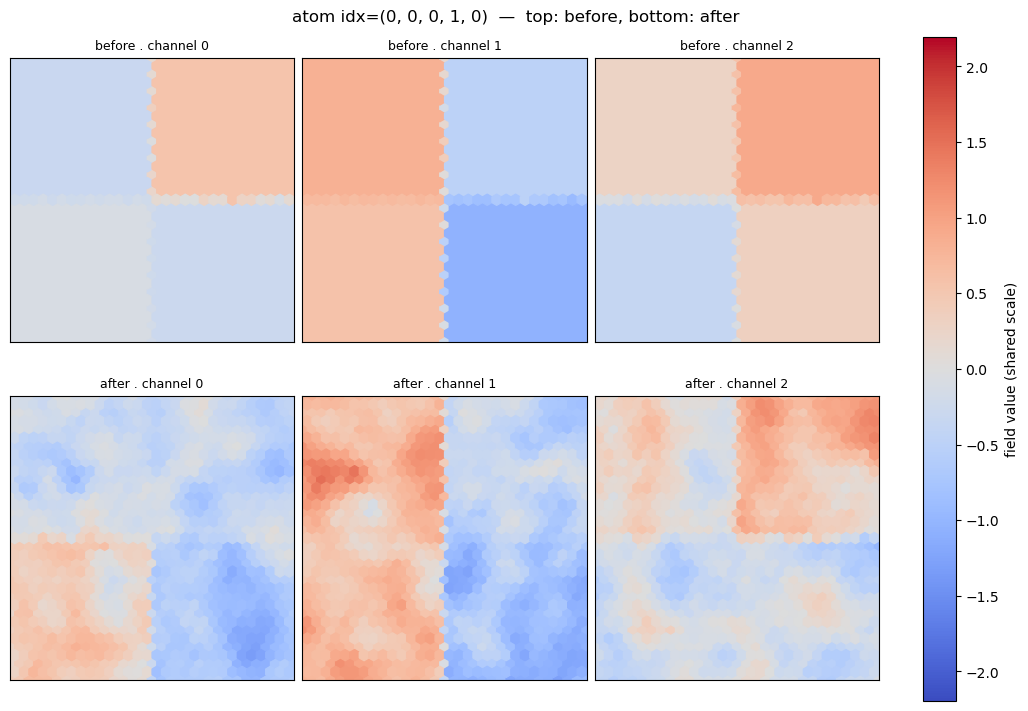

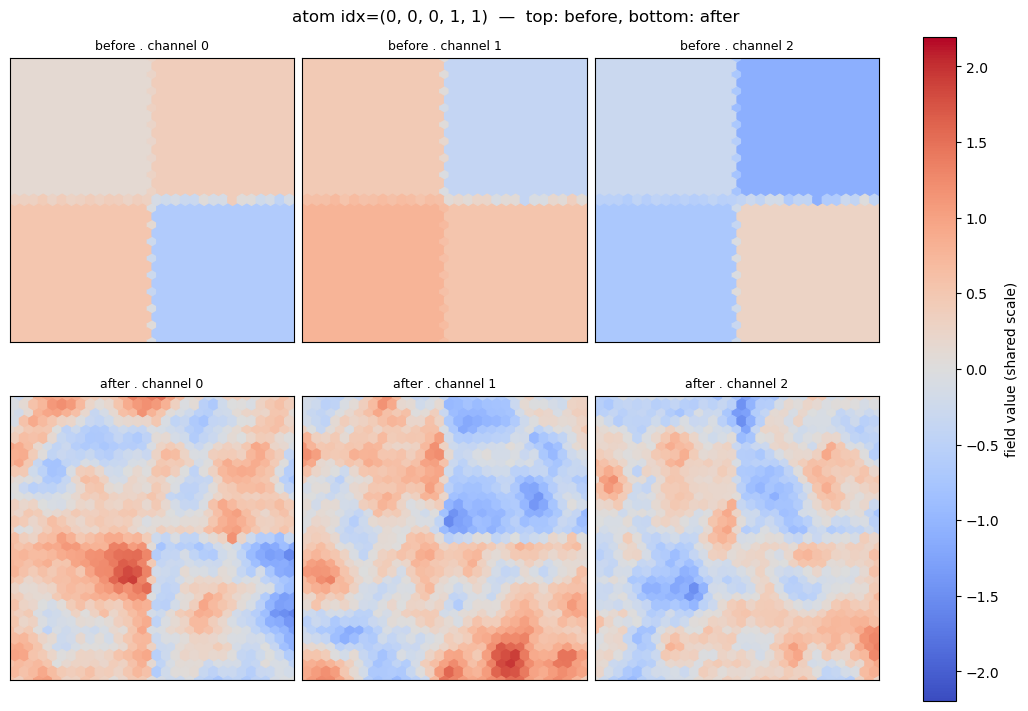

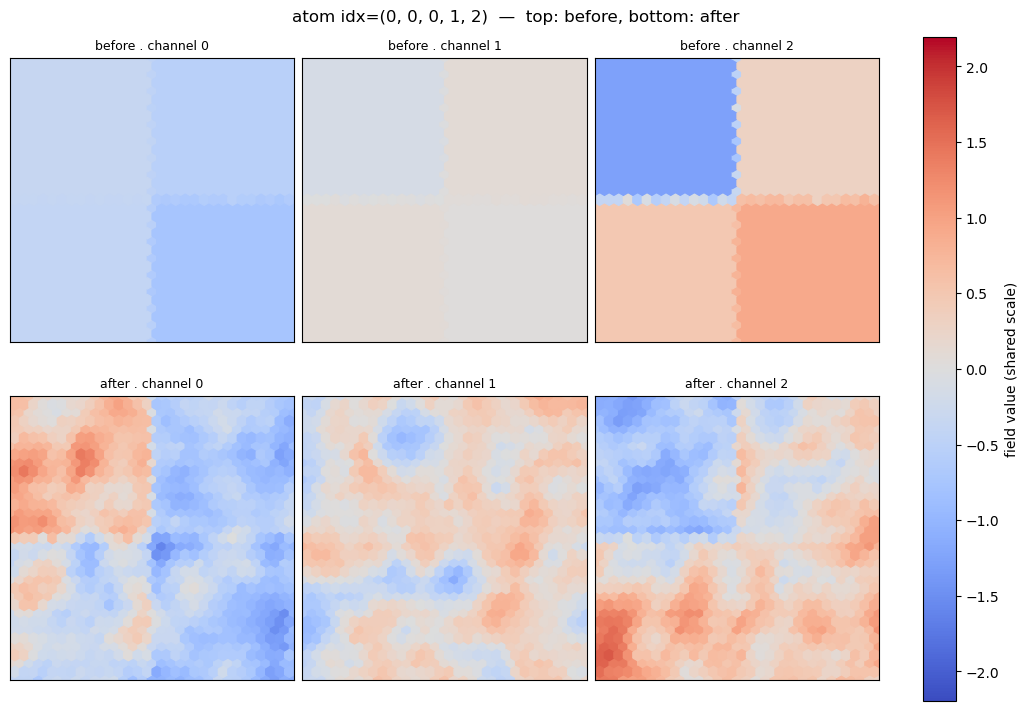

In [14]:
%autoreload 2
# Seed the same non-constant spatial atom in each channel.  The final index
# column is the channel for Fourier, Haar, and Voronoi dictionaries.
test_idx_3ch = demo_idx_3ch[1:2].repeat(3, 1)
test_idx_3ch[:, -1] = torch.arange(3, device=device)
atoms_3ch = fourier_3ch.get_atoms(coords_3ch, test_idx_3ch)   # (3, N, 3) real

isometry_3ch.shuffle_model_state(num_steps=20)
isometry_3ch.eval()
_, _, atoms_3ch_pushed = isometry_3ch.pushforward(
    coords_3ch, lad_3ch, atoms_3ch, rot_start_time=0.0, rot_end_time=1.0,
)

C = 3
# One symmetric scale for every atom, time, and channel: panel colour now
# encodes comparable signed magnitude instead of each hexbin auto-scaling.
channel_limit = torch.cat([atoms_3ch, atoms_3ch_pushed], dim=0).abs().max().item()
channel_limit = max(channel_limit, 1e-12)
for a in range(atoms_3ch.shape[0]):
    fig, axes = plt.subplots(2, C, figsize=(3.4 * C, 7.0), constrained_layout=True)
    image = None
    for c in range(C):
        image = show_scalar_2d(
            axes[0, c], coords_3ch, atoms_3ch[a][:, c:c + 1], title=f'before . channel {c}',
            cmap='coolwarm', vmin=-channel_limit, vmax=channel_limit,
        )
        show_scalar_2d(
            axes[1, c], coords_3ch, atoms_3ch_pushed[a][:, c:c + 1], title=f'after . channel {c}',
            cmap='coolwarm', vmin=-channel_limit, vmax=channel_limit,
        )
    index_text = ', '.join(str(value) for value in test_idx_3ch[a].tolist())
    fig.suptitle(f'atom idx=({index_text})  —  top: before, bottom: after')
    fig.colorbar(image, ax=axes.ravel().tolist(), label='field value (shared scale)')
    plt.show()

### Gram (isometry) check

The $\mathbb{R}^3$-valued Gram $G_{ab} = \langle Q\psi_a, Q\psi_b\rangle$ must match the initial Gram after the pushforward, even though individual atoms mix across channels. As in the 1-D case we sample the quadrature points **independently** for the initial and the pushed Gram, so matching heatmaps reflect the $L^2$ isometry rather than a shared point set.

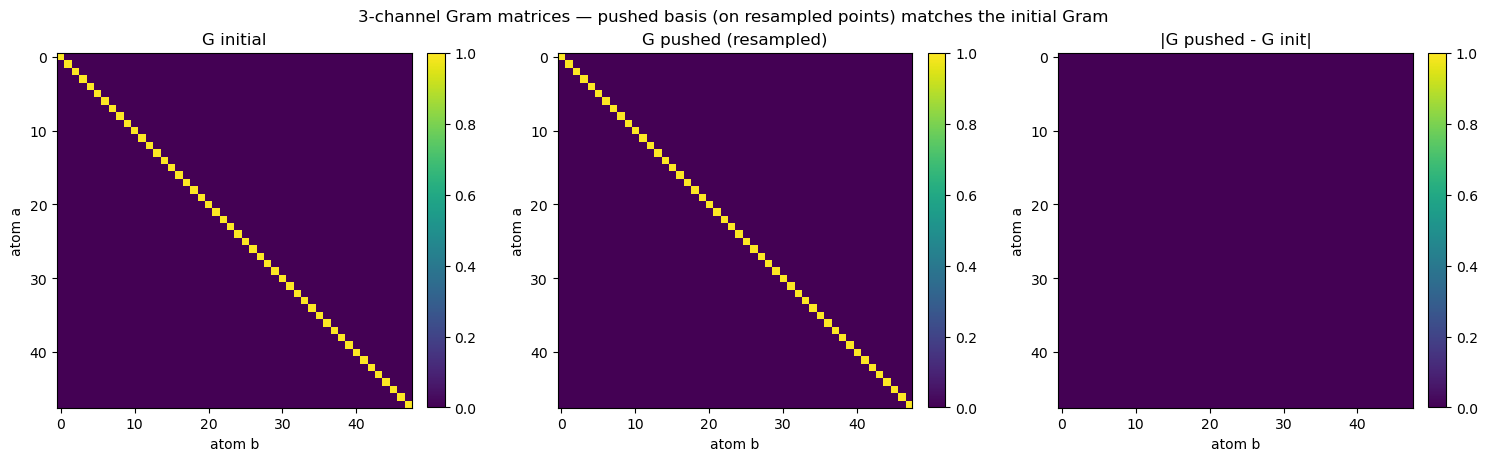

max |G_pushed - G_init| = 1.1168843627729075e-13


In [15]:
%autoreload 2
# Independent quadrature points for the initial vs the pushed Gram.
coords_init = SquareSampler(stratified=True, add_noise=True).sample(N_3ch).to(device)
coords_push = SquareSampler(stratified=True, add_noise=True).sample(N_3ch).to(device)
lad_init = torch.zeros(coords_init.shape[0], device=device)
lad_push = torch.zeros(coords_push.shape[0], device=device)

atoms_init = fourier_3ch.get_atoms(coords_init, gram_idx_3ch)
atoms_push = fourier_3ch.get_atoms(coords_push, gram_idx_3ch)
with torch.no_grad():
    _, _, atoms_push = isometry_3ch.pushforward(coords_push, lad_push, atoms_push, rot_start_time=0.0, rot_end_time=1.0)
    G_init   = pairwise_inner_product(atoms_init, atoms_init, lad_init)
    G_pushed = pairwise_inner_product(atoms_push, atoms_push, lad_push)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
vmin = min(G_init.min().item(), G_pushed.min().item())
vmax = max(G_init.max().item(), G_pushed.max().item())
for ax, G, ttl in zip(axes, [G_init, G_pushed, G_pushed - G_init],
                      ['G initial', 'G pushed (resampled)', '|G pushed - G init|']):
    im = ax.imshow(G.detach().cpu(), cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); ax.set_title(ttl)
    ax.set_xlabel('atom b'); ax.set_ylabel('atom a')
fig.suptitle('3-channel Gram matrices — pushed basis (on resampled points) matches the initial Gram')
plt.show()
print('max |G_pushed - G_init| =', (G_pushed - G_init).abs().max().item())

### Generator field on a specific channel

`visualize_generator_U` takes a `channel` argument, so you can inspect the generator columns $u_r(t,\cdot)$ on a chosen output channel of the multi-channel isometry.

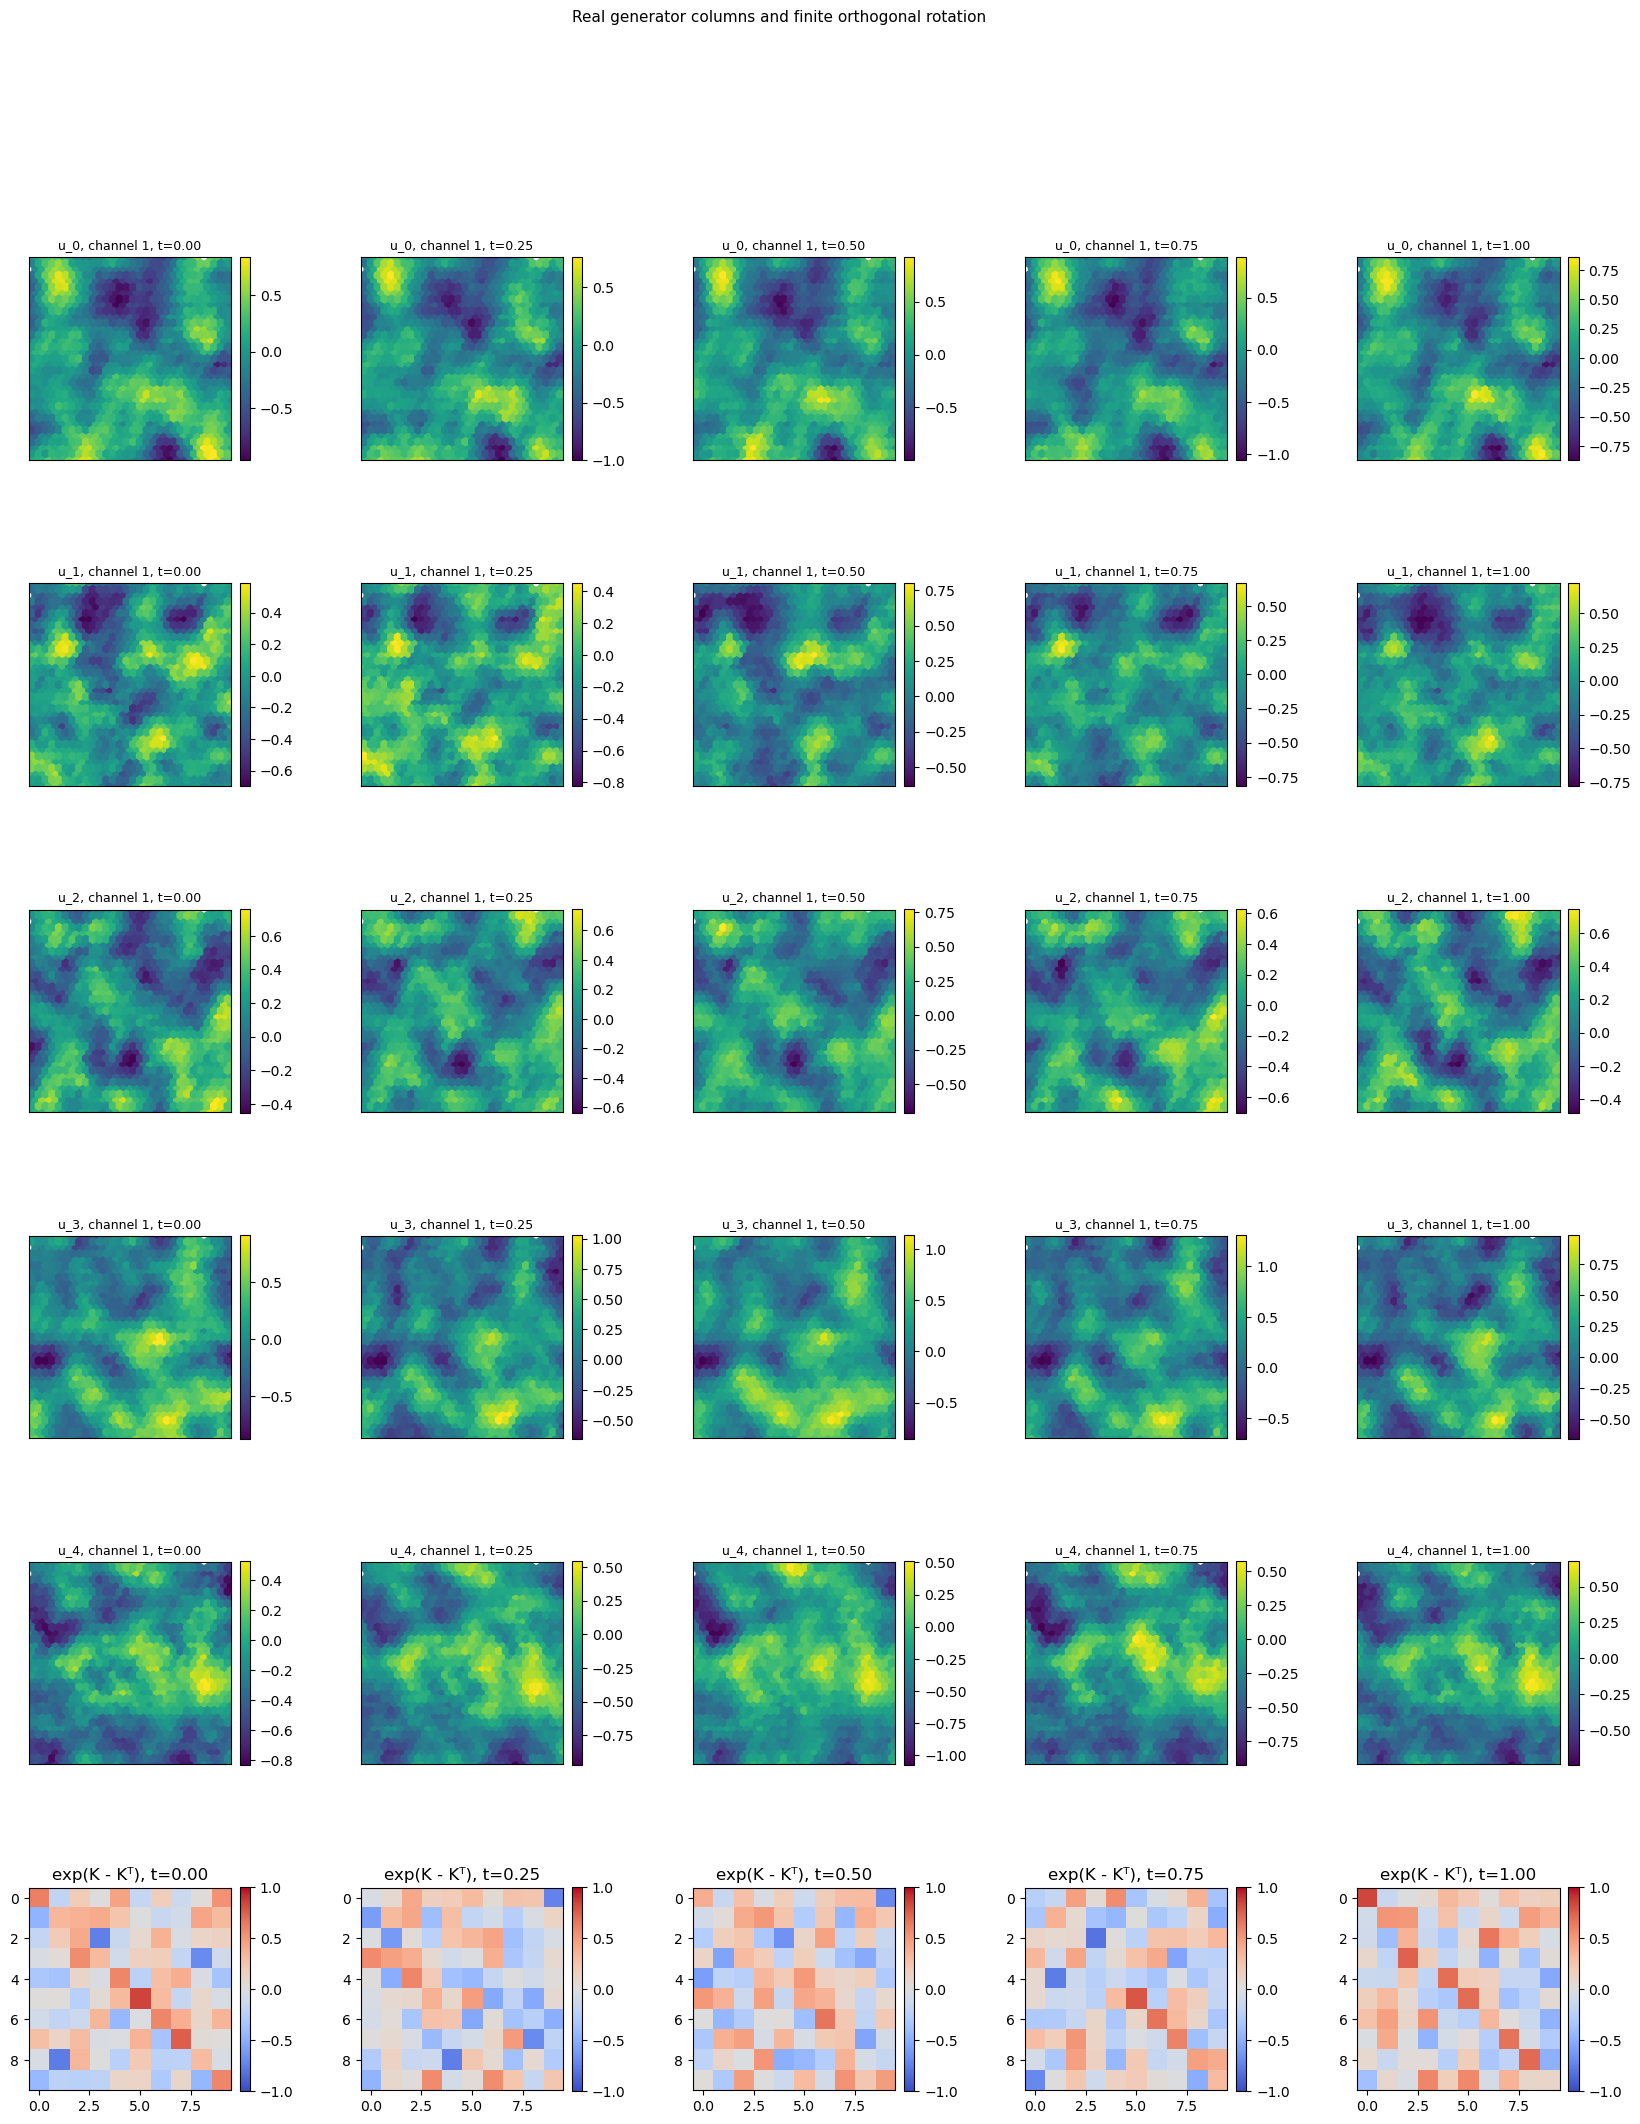

In [16]:
%autoreload 2
N_vis_3ch = 56
coords_vis_3ch = SquareSampler(stratified=True, add_noise=True).sample(N_vis_3ch).to(device)
timesteps_3ch = torch.linspace(0.0, 1.0, 5)

# inspect the generator columns restricted to channel 1
visualize_generator_U(eulerian_3ch, coords_vis_3ch, timesteps_3ch, device, channel=1)